(C) Copyright 2025 - ECMWF and individual contributors.

This software is licensed under the terms of the Apache Licence Version 2.0
which can be obtained at http://www.apache.org/licenses/LICENSE-2.0.
In applying this licence, ECMWF does not waive the privileges and immunities
granted to it by virtue of its status as an intergovernmental organisation nor
does it submit to any jurisdiction.

# POF Plotter

Importing all the necessary python libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import xarray as xr
import matplotlib as mpl
from cartopy import config
import cartopy.crs as ccrs
import cartopy as cart
import sys
import datetime
from matplotlib.colors import ListedColormap,LinearSegmentedColormap


Open Prediction Netcdf

In [2]:
year=2019
month=12


fire= xr.open_dataset(f"./outputs/POF_prediction_{year}_{month:02d}.nc")
fire = fire.assign_coords(longitude=((fire.longitude + 360) % 360)).sortby('longitude')
lats = fire.latitude.values
lons = fire.longitude.values
fire


<xarray.Dataset> Size: 2GB
Dimensions:           (time: 31, latitude: 1801, longitude: 3600)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 14kB 90.0 89.9 89.8 ... -89.9 -90.0
  * longitude         (longitude) float64 29kB 0.0 0.1 0.2 ... 359.7 359.8 359.9
Data variables:
    fire_probability  (time, latitude, longitude) float64 2GB ...

Define a subregion to plot

In [ ]:
lat1 = -10
lat2 = -45
lon1 = 110
lon2 = 155

sub_ds = fire.sel(
    latitude=slice(lat1, lat2), 
    longitude=slice(lon1, lon2)
)

sub_ds


<xarray.Dataset> Size: 39MB
Dimensions:           (time: 31, latitude: 350, longitude: 451)
Coordinates:
  * time              (time) object 248B 2019-12-01 00:00:00 ... 2019-12-31 0...
  * latitude          (latitude) float64 3kB -10.0 -10.1 -10.2 ... -44.8 -44.9
  * longitude         (longitude) float64 4kB 110.0 110.1 110.2 ... 154.9 155.0
Data variables:
    fire_probability  (time, latitude, longitude) float64 39MB ...

Create colour pallete

In [4]:
cols = ['#4a5a60','#edcc00','#edcc00','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e57d0f','#e21819','#e21819','#e21819','#e21819','#e21819','#000000','#000000']
test = ListedColormap(cols)

Define levels

In [5]:
index=0 # Which index to plot (1st of the month)

fires = sub_ds.fire_probability[index].values
plot_title = f"Probability of Fire Forecast for {sub_ds.time.values[index].strftime('%d %B %Y') }"

fires[fires>0.006]=0.006 # 1km

levels = np.arange(16)/2500 # 1km

print(np.shape(fires))
print(np.nanmax(fire.fire_probability.values))
print(np.nanmin(fire.fire_probability.values))
print(np.nanmean(fire.fire_probability.values))

(350, 451)
0.7821691036224365
7.712809946269772e-08
0.00037181633024126437


Plot

/opt/homebrew/Caskroom/miniforge/base/envs/POF_BOOK/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/homebrew/Caskroom/miniforge/base/envs/POF_BOOK/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


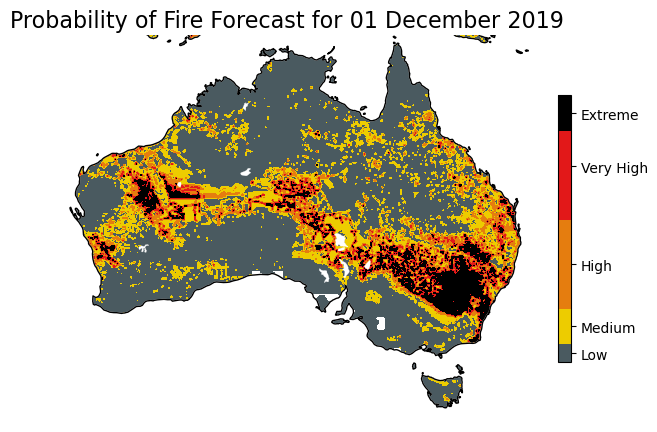

In [6]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

fig = ax.contourf(sub_ds.longitude, sub_ds.latitude, fires,levels=levels,vmin=0,vmax=0.006,transform=ccrs.PlateCarree(),cmap=test)

ax.add_feature(cart.feature.OCEAN,zorder=1,edgecolor='k',color='white')
ax.add_feature(cart.feature.BORDERS,linewidth=0.5,color='white')
ax.add_feature(cart.feature.LAKES,color='white', edgecolor='k', linewidth=0.2, zorder=2)

states_provinces = cart.feature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        edgecolor='black'
)

for spine in ax.spines.values():
   spine.set_visible(False)

cbar = plt.colorbar(fig,ticks=[0.0002,0.0008,0.0022,0.0044,0.0056],fraction=0.025, pad=0.04)
cbar.ax.set_yticklabels(['Low', 'Medium','High', 'Very High', 'Extreme'])

plt.title(plot_title, fontsize=16)

plt.tight_layout()

plt.savefig('./outputs/My_PoF_Plot.png', dpi=300)

